In [2]:
%load_ext autoreload
%autoreload 2

https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

In [1]:
import os
import sparrow as sp
import spatialdata as sd

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [2]:
#path = "/Users/arnedf/VIB/DATA/visium" # pick a path where the zarr store will be saved
#sdata=sp.datasets.visium_hd_example( bin_size=[ 2, 8, 16 ], output = os.path.join( path, "sdata_custom_binning_example.zarr" ) )
sdata = sd.read_zarr("/home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_zarr")


/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

In [7]:
import json

json_file = "/home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/binned_outputs/square_008um/spatial/scalefactors_json.json"

# Load the JSON file
with open(json_file, 'r') as f:
    scalefactors = json.load(f)

# Print the loaded JSON data
print(scalefactors)
spot_diameter_56um = scalefactors['spot_diameter_fullres'] * 7
print(spot_diameter_56um)


{'spot_diameter_fullres': 18.087961748248805, 'bin_size_um': 8.0, 'microns_per_pixel': 0.44228311135026166, 'tissue_lowres_scalef': 0.025127733, 'fiducial_diameter_fullres': 746.1284221152632, 'tissue_hires_scalef': 0.25127733, 'regist_target_img_scalef': 0.25127733}
126.61573223774164


create a grid

In [5]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_zarr
├── Images
│     ├── 'CAW009_full_image': DataTree[cyx] (3, 23878, 18889), (3, 11939, 9444), (3, 5969, 4722), (3, 2984, 2361), (3, 1492, 1180)
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│     └── 'CAW009_square_032um': GeoDataFrame shape: (28319, 1) (2D shapes)
└── Tab

In [8]:
# take shape of grid equal to full h&e image
se = sdata["CAW009_full_image"]["scale0"]["image"]
sdata = sp.im.add_grid_labels_layer(sdata, shape = se.shape[1:], size=spot_diameter_56um, output_shapes_layer="CAW009_square_056um",
                                    output_labels_layer="CAW009_square_056um_labels", grid_type="square", overwrite=True,
                                    chunks=256)

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

(Will have to do the step above on the HPC)

In [5]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_zarr
├── Images
│     ├── 'CAW009_full_image': DataTree[cyx] (3, 23878, 18889), (3, 11939, 9444), (3, 5969, 4722), (3, 2984, 2361), (3, 1492, 1180)
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     ├── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
│     └── 'Visium_HD_Liver_square_056um_labels': DataArray[yx] (23878, 18889)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│    

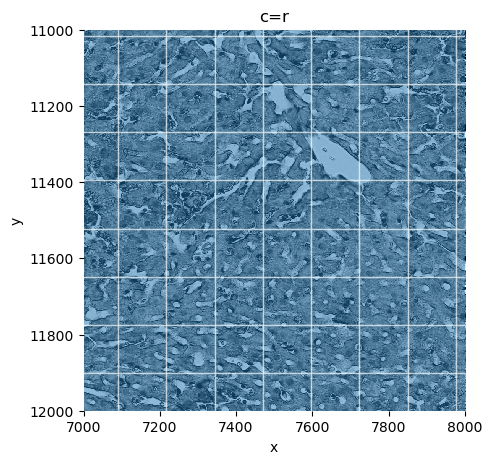

In [ ]:
# lets plot the grid
sp.pl.plot_shapes( sdata,
                  img_layer="CAW009_full_image",
                  shapes_layer="CAW009_square_056um", 
                  crd = [7000,8000,11000, 12000],
                  channel = "r",
                  figsize=(5,5)
                   )

In [28]:
# now do a custom binning using the generated labels layer 'square_labels'.
# below step should be quite fast, 50-ish seconds on mac m2
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_008um",
    labels_layer="CAW009_square_056um_labels",
    output_layer="square_056um",
    append = False,
    overwrite = True,
      )

2025-10-03 08:50:11,399 - sparrow.table._allocation - INFO - Calculating cell counts.
2025-10-03 08:50:14,095 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1         52
                       2         51
                       3         36
                       4         38
                       5         17
                       6         37
                       7         61
                       8         23
                       9         25
                      10         16
                      11         16
                      12         20
                      13         19
                      14         23
                      15         20
                      16         17
                      17         19
                      18          9
                      19         15
                      20         16
                      21         90
                      22         22
                      23

In [ ]:
# Convert the shapes to GeoDataFrames
gdf_8um = sdata.shapes['CAW009_square_008um']
gdf_8um.geometry = gdf_8um.geometry.centroid

gdf_56um = sdata["CAW009_square_056um"]


# sjoin can also be used
intersection = gpd.sjoin(gdf_8um, gdf_56um, how='inner', predicate='intersects')

# Group by the 56µm bin IDs and count the number of 8µm bins in each
intersection.groupby('index_right').size().plot(kind='hist', bins=30, figsize=(8, 6), title='Histogram of Intersection Counts')
intersection.groupby('index_right').size().describe() # Most are 49 -> this is correct

In [ ]:
# Create a frequency table for the counts
# Not exactly the same as sp.bin_counts
intersection.groupby('index_right').size().value_counts()

49    8222
48     203
21      87
7       62
1       53
2       52
4       37
6       36
3       35
47      34
28      33
46      33
14      30
9       24
8       23
39      23
41      22
42      21
45      21
13      20
31      19
43      19
5       19
17      19
11      19
22      18
16      18
12      17
44      17
15      17
38      17
32      17
24      16
35      16
19      16
37      16
34      16
20      16
27      15
40      15
23      15
10      14
26      13
30      12
25      12
29      11
36      10
18      10
33       6
Name: count, dtype: int64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd

In [32]:
adata = sdata["square_056um"]
sc.pp.calculate_qc_metrics(adata, inplace=True)

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

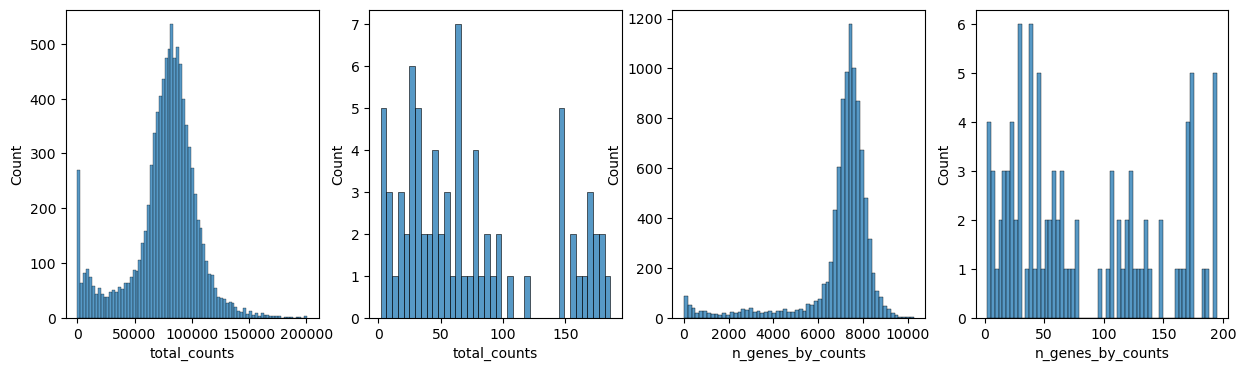

In [33]:


fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 200],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 200],
    kde=False,
    bins=60,
    ax=axs[3],
)

In [34]:
adata.var_names_make_unique()
adata.write_h5ad("/home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_056um.h5ad")

In [35]:
adata.obs["cell_ID"]

cells
1906_CAW009_square_056um_labels_43e1ef71      1906
1907_CAW009_square_056um_labels_43e1ef71      1907
1908_CAW009_square_056um_labels_43e1ef71      1908
1909_CAW009_square_056um_labels_43e1ef71      1909
1910_CAW009_square_056um_labels_43e1ef71      1910
                                             ...  
19802_CAW009_square_056um_labels_43e1ef71    19802
19803_CAW009_square_056um_labels_43e1ef71    19803
19804_CAW009_square_056um_labels_43e1ef71    19804
19810_CAW009_square_056um_labels_43e1ef71    19810
19817_CAW009_square_056um_labels_43e1ef71    19817
Name: cell_ID, Length: 9515, dtype: uint16

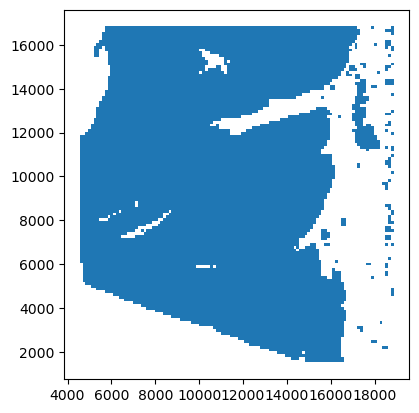

In [38]:
# Filter sdata["Visium_HD_Liver_square_032um"] to only include cells in adata.obs["cell_ID"]
cells_ids_in_tissue = sdata["CAW009_square_056um"].loc[adata.obs["cell_ID"]]
cells_ids_in_tissue.plot()

# Export the point object in two columns, x and y
df = pd.DataFrame({
    "x": cells_ids_in_tissue.centroid.x,
    "y": cells_ids_in_tissue.centroid.y
})

In [39]:
df.to_csv("/home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_056um_centroids.csv", index=True, header=True)

In [40]:
import scanpy as sc

adata = sc.read_h5ad("/home/chananchidas/visium-hd/data/Visium_HD_Liver_CAW009/Visium_HD_Liver_CAW009_056um.h5ad")

In [41]:
adata

AnnData object with n_obs × n_vars = 9515 × 19059
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'